In [15]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.ticker as ticker
import umap
from sklearn.preprocessing import StandardScaler
import matplotlib as mpl

In [16]:
# load the featurized polymer data
df = pd.read_excel('../data/Featurized Polymer SAXS Data.xlsx')

In [18]:
# define color palette
sunset = ['#9EBCF5', '#2D5FAC', '#F9AC2F','#EA7100', '#BA3B00', '#741905', '#BA9BD4', '#75439D', '#330956' ]

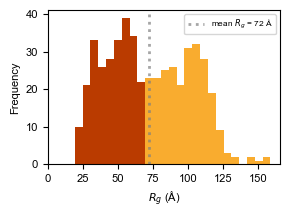

Total count: 493
Mean Rg: 72.3 Å


In [ ]:
# Radius of Gyration histogram

rg_values = df['Final Rg']

fig = plt.figure(figsize=(3, 2))

# Create histogram instead of KDE
counts, bins, patches = plt.hist(rg_values, bins=25, alpha=1, edgecolor='none')

# Find mean value
mean_rg = rg_values.mean()

# Color the histogram bars based on mean
for i, patch in enumerate(patches):
    bin_center = (bins[i] + bins[i+1]) / 2
    if bin_center <= mean_rg:
        patch.set_facecolor(sunset[4])
        patch.set_alpha(1)
    else:
        patch.set_facecolor(sunset[2])
        patch.set_alpha(1)

# Draw mean line
plt.axvline(x=mean_rg, color='gray', linestyle=':', linewidth=2, alpha=0.7, label=f"mean $R_g$ = {np.round(mean_rg,0):.0f} Å")

plt.xlabel("$R_g$ (Å)", fontsize=8)
plt.xticks([0, 25, 50, 75, 100, 125, 150], fontsize=8)
plt.yticks([0, 10, 20, 30, 40], fontsize=8)
plt.ylabel("Frequency", fontsize=8)
plt.xlim(left=0)
plt.ylim(bottom=0)
plt.legend(fontsize=6, loc='upper right')
plt.show()

# save the figure in high res (300 dpi)
fig.savefig(r'..\imgs\visualization\Rg histogram.svg', dpi=600, bbox_inches='tight', transparent=True)
fig.savefig(r'..\imgs\visualization\Rg histogram.pdf', dpi=600, bbox_inches='tight', transparent=True)
# Print some histogram statistics
print(f'Total count: {len(rg_values)}')
print(f'Mean Rg: {mean_rg:.1f} Å')

C:\Users\Elena\AppData\Local\Temp\ipykernel_31436\323892994.py:20: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=cluster_counts.index, y=cluster_counts.values, palette=palette, order=order)


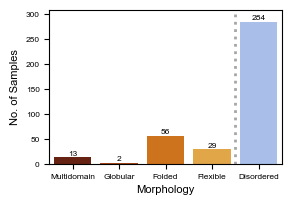

In [20]:
# Kratky Folding Order Bar Plot
cluster_colors = {
    2: sunset[0],  # disordered
    4: sunset[2],   # flexible
    0: sunset[3],  # folded
    3: sunset[4],  # globular
    1: sunset[5]  # multidomain
}

palette = [sunset[5], sunset[4], sunset[3], sunset[2], sunset[0]]

# Desired order: globular (3), folded (0), flexible (4), disordered (2), polydisperse (1)
order = [1, 3, 0, 4, 2]
labels = ['Multidomain', 'Globular', 'Folded', 'Flexible', 'Disordered']

# Count occurrences for all clusters, fill missing with 0
cluster_counts = df['GMM Cluster'].value_counts().reindex(order, fill_value=0)

fig = plt.figure(figsize=(3,2))
sns.barplot(x=cluster_counts.index, y=cluster_counts.values, palette=palette, order=order)
plt.xlabel('Morphology', fontsize=8)
plt.ylabel('No. of Samples', fontsize=8)
# plt.title('Distribution of GMM Clusters')
plt.gca().yaxis.set_major_formatter(ticker.StrMethodFormatter('{x:,.0f}'))
plt.xticks(ticks=np.arange(5), labels=labels, fontsize=6)
plt.yticks([0,50,100,150,200,250,300], fontsize=6)

plt.axvline(x=3.5, color='gray', linestyle=':', linewidth=2, alpha=0.7)

# Add space at top for value labels
plt.ylim(0, cluster_counts.values.max() + 25)

for i, v in enumerate(cluster_counts.values):
    plt.text(i, v + 4, str(v), ha='center', fontsize=6)
plt.show()



# save fig
fig.savefig(r'..\imgs\visualization\kratky folding order histogram.svg', dpi=600, bbox_inches='tight', transparent=True)

c:\Users\Elena\anaconda3\envs\scnp_env\lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


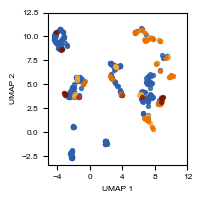

In [32]:
# UMAP, hued by Kratky Folding Order

# Select features for UMAP
features_umap = ['Concentration', 'Net Charge', 'LogP', 'Molecular Weight (Da)', 'Surface Area (Å²)', 'HBT', 'Neutral Fraction'] 
# Drop rows with missing values in selected features
data_umap = df[features_umap].dropna()
# Standardize the features
scaler = StandardScaler()
umap_model = umap.UMAP(n_components=2, random_state=42)
umap_result = umap_model.fit_transform(scaler.fit_transform(data_umap))
# Create a DataFrame with UMAP results
umap_df = pd.DataFrame(data=umap_result, columns=['UMAP1', 'UMAP2'])
# Plot UMAP results colored by GMM clusters
fig = plt.figure(figsize=(2,2))

# Create UMAP dataframe with cluster information
umap_df_hue = umap_df.copy()
umap_df_hue['GMM_Cluster'] = df.loc[data_umap.index, 'GMM Cluster'].values

# Define cluster colors and labels
cluster_labels_dict = {
    2: 'Disordered',
    4: 'Flexible',
    0: 'Folded',
    3: 'Globular',
    1: 'Multidomain'  
}

# Define colors for each cluster

#'#8FD181', '#9890cb','#6862ab', '#48428e', '#231f5a'
cluster_colors = {
    2: '#2D5FAC',  # disordered
    4: '#F9AC2F',   # flexible
    0: '#EA7100',  # folded
    3: '#BA3B00',  # globular
    1: '#741905'  # multidomain
}
# Create scatter plot with cluster-based coloring
for cluster in [2, 4, 0, 3, 1]:
    if cluster in umap_df_hue['GMM_Cluster'].values:
        cluster_data = umap_df_hue[umap_df_hue['GMM_Cluster'] == cluster]
        plt.scatter(cluster_data['UMAP1'], cluster_data['UMAP2'], 
                    c=cluster_colors[cluster], 
                    label=cluster_labels_dict[cluster],
                    alpha=0.8, s=8)

#plt.legend(fontsize=6, markerscale=0.7, frameon=True, loc='best', bbox_to_anchor=(1.1,1))
plt.xticks([-4, 0, 4, 8, 12], fontsize=6)
plt.yticks([-2.5, 0, 2.5, 5, 7.5, 10, 12.5], fontsize=6)
plt.xlabel('UMAP 1', fontsize=6)
plt.ylabel('UMAP 2', fontsize=6)
plt.tight_layout()
plt.show()

fig.savefig(r'..\imgs\visualization\UMAP kratky folding order.svg', dpi=600, bbox_inches='tight', transparent=True)

c:\Users\Elena\anaconda3\envs\scnp_env\lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
C:\Users\Elena\AppData\Local\Temp\ipykernel_31436\3046240187.py:42: UserWarning: Glyph 8491 (\N{ANGSTROM SIGN}) missing from font(s) Arial.
  plt.tight_layout()
c:\Users\Elena\anaconda3\envs\scnp_env\lib\site-packages\IPython\core\pylabtools.py:152: UserWarning: Glyph 8491 (\N{ANGSTROM SIGN}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


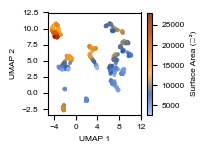

C:\Users\Elena\AppData\Local\Temp\ipykernel_31436\3046240187.py:45: UserWarning: Glyph 8491 (\N{ANGSTROM SIGN}) missing from font(s) Arial.
  fig.savefig(r'..\imgs\visualization\UMAP surface area.svg', dpi=600, bbox_inches='tight', transparent=True)


In [31]:
# UMAP visualization, hued by Surface Area

# Select features for UMAP
features_umap = ['Concentration', 'Net Charge', 'LogP', 'Molecular Weight (Da)', 'Surface Area (Å²)', 'HBT', 'Neutral Fraction']
# Drop rows with missing values in selected features
data_umap = df[features_umap].dropna()
# Standardize the features
scaler = StandardScaler()
umap_model = umap.UMAP(n_components=2, random_state=42)
umap_result = umap_model.fit_transform(scaler.fit_transform(data_umap))
# Create a DataFrame with UMAP results
umap_df = pd.DataFrame(data=umap_result, columns=['UMAP1', 'UMAP2'])

# Plot UMAP results colored by Surface Area (Å²) values

sunset = ['#9EBCF5', '#2D5FAC', '#F9AC2F','#EA7100', '#BA3B00', '#741905', '#BA9BD4', '#75439D', '#330956' ]

cmap = mpl.colors.LinearSegmentedColormap.from_list('custom', sunset[0:6])
fig = plt.figure(figsize=(2,1.5))

# Create UMAP dataframe with Surface Area (Å²) information
umap_df_hue = umap_df.copy()
umap_df_hue['Surface Area (Å²)'] = df.loc[data_umap.index, 'Surface Area (Å²)'].values

# Remove any NaN values that could cause rendering issues
mask = ~np.isnan(umap_df_hue['Surface Area (Å²)'])
umap_df_clean = umap_df_hue[mask]

# Create scatter plot with Surface Area (Å²)-based coloring
sc = plt.scatter(umap_df_clean['UMAP1'], umap_df_clean['UMAP2'], 
                c=umap_df_clean['Surface Area (Å²)'], cmap=cmap, 
                alpha=0.8, s=8, edgecolors='none')

cbar = plt.colorbar(sc)
cbar.set_label('Surface Area (Å²)', fontsize=6)
cbar.set_ticks([5000, 10000, 15000, 20000, 25000])
cbar.ax.tick_params(labelsize=6)
plt.xticks([-4, 0, 4, 8, 12], fontsize=6)
plt.yticks([-2.5, 0, 2.5, 5, 7.5, 10, 12.5], fontsize=6) 
plt.xlabel('UMAP 1', fontsize=6)
plt.ylabel('UMAP 2', fontsize=6)
plt.tight_layout()
plt.show()

fig.savefig(r'..\imgs\visualization\UMAP surface area.svg', dpi=600, bbox_inches='tight', transparent=True)

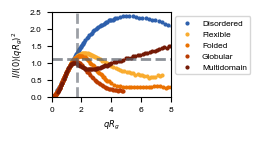

In [23]:
# kratky visualizations

plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['font.sans-serif'] = ['Arial']
plt.rcParams['font.size'] = 6

# load four files for kratky visualization: globular, folded, flexible, disordered
multidomain = pd.read_excel('../data/kratky vis/multidomain_poly76_10_mgmL_Dimless_Kratky.xlsx')
globular = pd.read_excel('../data/kratky vis/globular_13158_10_mgmL_Dimless_Kratky.xlsx')
folded = pd.read_excel('../data/kratky vis/folded_180744_10_mgmL_Dimless_Kratky.xlsx')
flexible = pd.read_excel('../data/kratky vis/flexible_209306_10_mgmL_Dimless_Kratky.xlsx')
disordered = pd.read_excel('../data/kratky vis/disordered_210016_10_mgmL_Dimless_Kratky.xlsx')

sunset = ['#9EBCF5', '#2D5FAC', '#F9AC2F','#EA7100', '#BA3B00', '#741905', '#BA9BD4', '#75439D', '#330956' ]

# plot all the kratky plots overlaid
plt.figure(figsize=(1.54,1.10))
plt.scatter(disordered['x'], disordered['y'], label='Disordered', color=sunset[1], s=4)
plt.scatter(flexible['x'], flexible['y'], label='Flexible', color=sunset[2], s=4)
plt.scatter(folded['x'], folded['y'], label='Folded', color=sunset[3], s=4)
plt.scatter(globular['x'], globular['y'], label='Globular', color=sunset[4], s=4)
plt.scatter(multidomain['x'], multidomain['y'], label='Multidomain', color=sunset[5], s=4)
plt.xlabel('$q R_g$')
plt.ylabel('$I/I(0) (q R_g)^2$')

# add crosshairs that intersect at (sqrt(3), 3/e)
plt.axhline(y=3/2.718, color='#5B616B', linestyle='--', linewidth=2, alpha=0.7)
plt.axvline(x=3**0.5, color='#5B616B', linestyle='--', linewidth=2, alpha=0.6)

# set the x lim to 0-8
plt.xlim(0, 8)
plt.xticks([0,2,4,6,8])
plt.ylim(0,2.5)
plt.yticks([0,0.5,1.0,1.5,2.0,2.5])
# plt.tight_layout()
plt.legend(loc='upper right', fontsize=6, bbox_to_anchor=(1.7,1.0))
# plt.show()

# save in high resolution
plt.savefig('../imgs/kratky plots/representative kratky morphologies.svg', dpi=600, bbox_inches='tight', transparent=True)

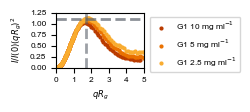

In [24]:
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['font.sans-serif'] = ['Arial']
plt.rcParams['font.size'] = 6

# concentration dependence of G1, globular polymer 13158
g1_10 = pd.read_excel('../data/kratky vis/globular_13158_10_mgmL_Dimless_Kratky.xlsx')
g1_5 = pd.read_excel('../data/kratky vis/G1_5mgmL_Dimless_Kratky.xlsx')
g1_2p5 = pd.read_excel('../data/kratky vis/G1_2mgmL_Dimless_Kratky.xlsx')

sunset = ['#9EBCF5', '#2D5FAC', '#F9AC2F','#EA7100', '#BA3B00', '#741905', '#BA9BD4', '#75439D', '#330956' ]

# plot all the kratky plots overlaid
plt.figure(figsize=(1.54,1.10))
plt.scatter(g1_10['x'], g1_10['y'], label='G1 10 mg ml$^{-1}$', color=sunset[4], s=4)
plt.scatter(g1_5['x'], g1_5['y'], label='G1 5 mg ml$^{-1}$', color=sunset[3], s=4)
plt.scatter(g1_2p5['x'], g1_2p5['y'], label='G1 2.5 mg ml$^{-1}$', color=sunset[2], s=4)

plt.xlabel('$q R_g$')
plt.ylabel('$I/I(0) (q R_g)^2$')

# add crosshairs that intersect at (sqrt(3), 3/e)
plt.axhline(y=3/2.718, color='#5B616B', linestyle='--', linewidth=2, alpha=0.7)
plt.axvline(x=3**0.5, color='#5B616B', linestyle='--', linewidth=2, alpha=0.6)

# set the x lim to 0-8
plt.xlim(0, 5)
plt.xticks([0,1, 2, 3, 4, 5])
plt.ylim(0,1.25)
plt.yticks([0,0.25,0.5,0.75,1.0,1.25])
plt.tight_layout()
plt.legend(loc='upper right', fontsize=6, bbox_to_anchor=(2.15,1.0))
# plt.show()

# save in high resolution
plt.savefig('../imgs/kratky plots/G1 concentration dependence.svg', dpi=600, bbox_inches = 'tight')

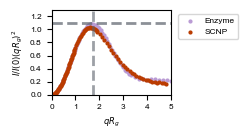

In [25]:
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['font.sans-serif'] = ['Arial']
plt.rcParams['font.size'] = 6

# gox vs g1 comparison

SCNP = pd.read_excel('../data/kratky vis/globular_13158_10_mgmL_Dimless_Kratky.xlsx')
enzyme = pd.read_excel('../data/kratky vis/GOx_10_s_Dimless_Kratky.xlsx')
sunset = ['#9EBCF5', '#2D5FAC', '#F9AC2F','#EA7100', '#BA3B00', '#741905', '#BA9BD4', '#75439D', '#330956' ]

# plot all the kratky plots overlaid
plt.figure(figsize=(1.54,1.10))

plt.scatter(enzyme['x'], enzyme['y'], label='Enzyme', color=sunset[6], s=4)
plt.scatter(SCNP['x'], SCNP['y'], label='SCNP', color=sunset[4], s=4)


plt.xlabel('$q R_g$')
plt.ylabel('$I/I(0) (q R_g)^2$')

# add crosshairs that intersect at (sqrt(3), 3/e)
plt.axhline(y=3/2.718, color='#5B616B', linestyle='--', linewidth=2, alpha=0.7)
plt.axvline(x=3**0.5, color='#5B616B', linestyle='--', linewidth=2, alpha=0.6)

plt.xlim(0, 5)
plt.xticks([0,1,2,3,4,5],fontsize=6)
plt.ylim(0,1.3)
plt.yticks([0,0.2,0.4,0.6,0.8,1.0,1.2],fontsize=6)
# plt.tight_layout()
plt.legend(loc='upper right', fontsize=6, bbox_to_anchor=(1.6,1.0))
# plt.show()

# save in high resolution
plt.savefig('../imgs/kratky plots/g1 gox comparison.svg', dpi=600, bbox_inches = 'tight', transparent=True)

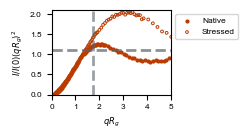

In [26]:
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['font.sans-serif'] = ['Arial']
plt.rcParams['font.size'] = 6

# g1 pre and post stress comparison
native = pd.read_excel('../data/kratky vis/G1_N_Dimless_Kratky.xlsx')
stressed = pd.read_excel('../data/kratky vis/G1_S_Dimless_Kratky.xlsx')

sunset = ['#9EBCF5', '#2D5FAC', '#F9AC2F','#EA7100', '#BA3B00', '#741905', '#BA9BD4', '#75439D', '#330956' ]

# plot all the kratky plots overlaid
plt.figure(figsize=(1.54,1.10))


plt.scatter(native['x'], native['y'], label='Native', color=sunset[4], s=4)
plt.scatter(stressed['x'], stressed['y'], label='Stressed', edgecolors=sunset[4], marker='o', facecolor='none', linewidths=0.7, s=4)


plt.xlabel('$q R_g$')
plt.ylabel('$I/I(0) (q R_g)^2$')

# add crosshairs that intersect at (sqrt(3), 3/e)
plt.axhline(y=3/2.718, color='#5B616B', linestyle='--', linewidth=2, alpha=0.7)
plt.axvline(x=3**0.5, color='#5B616B', linestyle='--', linewidth=2, alpha=0.6)

# set the x lim to 0-8
plt.xlim(0, 5)
plt.xticks([0,1,2,3,4,5],fontsize=6)
plt.ylim(0,2.1)
plt.yticks([0,0.5,1.0,1.5,2.0],fontsize=6)
# plt.tight_layout()
plt.legend(loc='upper right', fontsize=6, bbox_to_anchor=(1.6,1.0))
# plt.show()

# save in high resolution
plt.savefig('../imgs/kratky plots/g1 native vs stressed.svg', dpi=600, bbox_inches = 'tight', transparent=True)

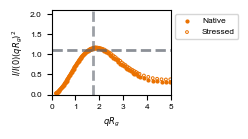

In [27]:
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['font.sans-serif'] = ['Arial']
plt.rcParams['font.size'] = 6

# g2 (f1) pre and post stress comparison
native = pd.read_excel('../data/kratky vis/G2_N_Dimless_Kratky.xlsx')
stressed = pd.read_excel('../data/kratky vis/G2_S_Dimless_Kratky.xlsx')

sunset = ['#9EBCF5', '#2D5FAC', '#F9AC2F','#EA7100', '#BA3B00', '#741905', '#BA9BD4', '#75439D', '#330956' ]

# plot all the kratky plots overlaid
plt.figure(figsize=(1.54,1.10))


plt.scatter(native['x'], native['y'], label='Native', color=sunset[3], s=4)
plt.scatter(stressed['x'], stressed['y'], label='Stressed', edgecolors=sunset[3], marker='o', facecolor='none', linewidths=0.7, s=4)


plt.xlabel('$q R_g$')
plt.ylabel('$I/I(0) (q R_g)^2$')

# add crosshairs that intersect at (sqrt(3), 3/e)
plt.axhline(y=3/2.718, color='#5B616B', linestyle='--', linewidth=2, alpha=0.7)
plt.axvline(x=3**0.5, color='#5B616B', linestyle='--', linewidth=2, alpha=0.6)

# set the x lim to 0-8
plt.xlim(0, 5)
plt.xticks([0,1,2,3,4,5],fontsize=6)
plt.ylim(0,2.1)
plt.yticks([0,0.5,1.0,1.5,2.0],fontsize=6)
# plt.tight_layout()
plt.legend(loc='upper right', fontsize=6, bbox_to_anchor=(1.6,1.0))
# plt.show()

# save in high resolution
plt.savefig('../imgs/kratky plots/f1 native vs stressed.svg', dpi=600, bbox_inches = 'tight', transparent = True)

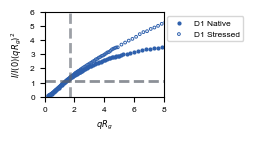

In [28]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['font.sans-serif'] = ['Arial']
plt.rcParams['font.size'] = 6

# d1 pre and post stress comparison
native = pd.read_excel('../data/kratky vis/D1_N_Dimless_Kratky.xlsx')
stressed = pd.read_excel('../data/kratky vis/D1_S_Dimless_Kratky.xlsx')

sunset = ['#9EBCF5', '#2D5FAC', '#F9AC2F','#EA7100', '#BA3B00', '#741905', '#BA9BD4', '#75439D', '#330956' ]

# plot all the kratky plots overlaid
plt.figure(figsize=(1.54,1.10))


plt.scatter(native['x'], native['y'], label='D1 Native', color=sunset[1], s=4)
plt.scatter(stressed['x'], stressed['y'], label='D1 Stressed', edgecolors=sunset[1], marker='o', facecolor='none', linewidths=0.7, s=4)


plt.xlabel('$q R_g$')
plt.ylabel('$I/I(0) (q R_g)^2$')

# add crosshairs that intersect at (sqrt(3), 3/e)
plt.axhline(y=3/2.718, color='#5B616B', linestyle='--', linewidth=2, alpha=0.7)
plt.axvline(x=3**0.5, color='#5B616B', linestyle='--', linewidth=2, alpha=0.6)

# set the x lim to 0-8
plt.xlim(0, 8)
plt.xticks([0,2,4,6,8])
plt.ylim(0,6)
plt.yticks([0,1, 2, 3, 4, 5, 6])
# plt.tight_layout()
plt.legend(loc='upper right', fontsize=6, bbox_to_anchor=(1.7,1))
# plt.show()

# save in high resolution
plt.savefig('../imgs/kratky plots/d1 native vs stressed.svg', dpi=600, bbox_inches='tight', transparent = True)

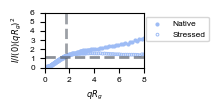

In [29]:
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['font.sans-serif'] = ['Arial']
plt.rcParams['font.size'] = 6

# d2 pre and post stress comparison
native = pd.read_excel('../data/kratky vis/D2_N_Dimless_Kratky.xlsx')
stressed = pd.read_excel('../data/kratky vis/D2_S_Dimless_Kratky.xlsx')

sunset = ['#9EBCF5', '#2D5FAC', '#F9AC2F','#EA7100', '#BA3B00', '#741905', '#BA9BD4', '#75439D', '#330956' ]

# plot all the kratky plots overlaid
plt.figure(figsize=(1.54,1.10))


plt.scatter(native['x'], native['y'], label='Native', color=sunset[0], s=4)
plt.scatter(stressed['x'], stressed['y'], label='Stressed', edgecolors=sunset[0], marker='o', facecolor='none', linewidths=0.7, s=4)


plt.xlabel('$q R_g$')
plt.ylabel('$I/I(0) (q R_g)^2$')

# add crosshairs that intersect at (sqrt(3), 3/e)
plt.axhline(y=3/2.718, color='#5B616B', linestyle='--', linewidth=2, alpha=0.7)
plt.axvline(x=3**0.5, color='#5B616B', linestyle='--', linewidth=2, alpha=0.6)

# set the x lim to 0-8
plt.xlim(0, 8)
plt.xticks([0,2,4,6,8])
plt.ylim(0,6)
plt.yticks([0,1, 2, 3, 4, 5, 6])
plt.tight_layout()
plt.legend(loc='upper right', fontsize=6, bbox_to_anchor=(1.7,1.0))
# plt.show()

# save in high resolution
plt.savefig('../imgs/kratky plots/d2 native vs stressed.svg', dpi=600, bbox_inches='tight', transparent = True)